# Phase 1 — Cohort overview & exploratory data analysis

Goal: understand the SUPPORT cohort before any modeling decision — how many
patients, how much censoring, what the overall and stratified survival curves
look like, and which raw values are physiologically implausible. All logic
lives in `support_survival`; this notebook only calls it and narrates.

In [1]:
from support_survival import data, eda

df = data.load()
df.shape

(8873, 16)

## Cohort definition

No records are excluded: the analysis cohort is the full SUPPORT extract as
shipped by the DeepSurv preprocessing (~8,900 seriously ill hospitalized
patients across 5 US medical centers), with no additional inclusion/exclusion
criteria applied at this stage. See `reports/model_card.md` for the recorded
rationale.

In [2]:
eda.outcome_summary(df)

,n_patients,n_deaths,n_censored,event_rate,median_followup_days,max_followup_days
0,8873,6036,2837,0.680266,231.0,2029.0


**Reading this table:** every patient has a positive follow-up time and a
binary event indicator. ~68% of patients died during observed follow-up and
~32% were right-censored (alive at last contact, or follow-up ended) — this
matches the event rate documented in the model card. Censored patients are
**not** "cured"; the Kaplan-Meier estimator below accounts for this
correctly, which is why we don't just compute a naive death rate at a fixed
horizon.

np.float64(231.0)

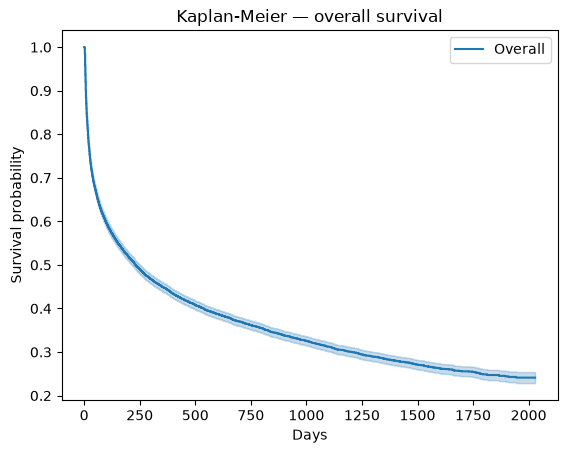

In [3]:
kmf = eda.plot_km_overall(df, save_path=eda.REPORTS_DIR / "km_overall.png")
kmf.median_survival_time_

## Feature distributions & data-quality scan

Histograms first, to eyeball skew and obvious outliers; then an explicit scan
for zero values in columns where zero is not a plausible clinical
measurement (a living patient cannot have zero blood pressure, heart rate,
respiration rate, or serum sodium — as opposed to `n_comorbidities` or the
`diabetes`/`dementia`/`cancer` flags, where 0 is a legitimate value).

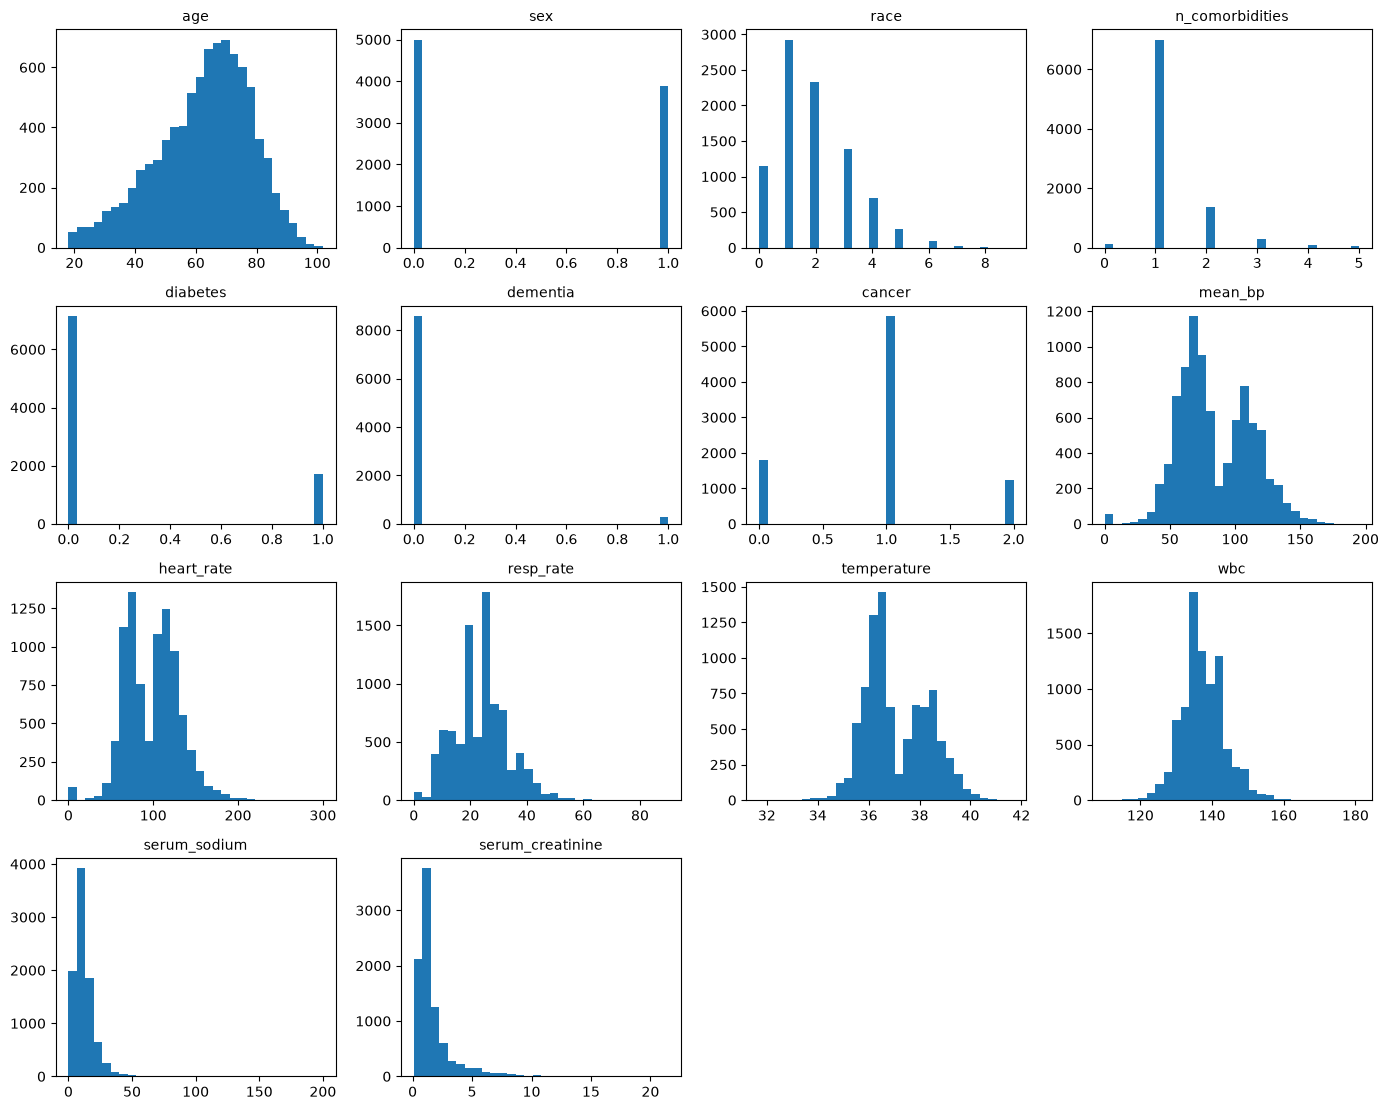

In [4]:
_ = eda.plot_feature_distributions(
    df, data.FEATURES, save_path=eda.REPORTS_DIR / "feature_distributions.png"
)

In [5]:
eda.scan_implausible(df, data.FEATURES)

,column,n_zero,pct_zero
0,dementia,8586,0.967655
1,diabetes,7150,0.805815
2,sex,4995,0.562944
3,cancer,1786,0.201285
4,race,1148,0.129381
5,n_comorbidities,110,0.012397
6,heart_rate,82,0.009242
7,resp_rate,65,0.007326
8,mean_bp,51,0.005748
9,serum_sodium,10,0.001127


**Findings:** `mean_bp` has 51 zero values (0.6%) — already treated as
missing in `features.flag_implausible` (Phase 0 decision, confirmed here).
`heart_rate` (82, 0.9%), `resp_rate` (65, 0.7%), and `serum_sodium` (10,
0.1%) are zero for a small number of patients and are equally implausible
for a live patient — these are **candidates to add to
`IMPLAUSIBLE_ZERO_COLS` in Phase 2**, not fixed here. Categorical/count
columns (`sex`, `race`, `n_comorbidities`, `diabetes`, `dementia`, `cancer`)
also show zeros, but zero is a legitimate value for all of them and requires
no action.

## Stratified Kaplan-Meier — by cancer status

`cancer` has three levels in SUPPORT (0 = none, 1 = present, 2 =
metastatic), so we use the multivariate log-rank test rather than the
two-sample version.

np.float64(6.712671542671685e-129)

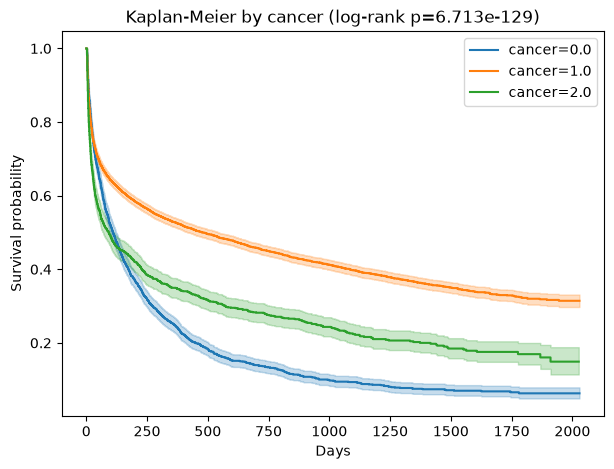

In [6]:
result = eda.plot_km_by_group(df, "cancer", save_path=eda.REPORTS_DIR / "km_by_cancer.png")
result["logrank"].p_value

**Interpretation:** the curves separate visibly and the log-rank test
rejects equal survival across the three cancer-status groups (p < 0.05),
consistent with clinical expectation — cancer status, and metastatic status
in particular, materially affects survival in this cohort. This motivates
including `cancer` as a covariate in the Cox model in Phase 4, and checking
whether its effect is proportional-hazards compliant.

## Summary for Phase 2

- No records excluded from the cohort (see "Cohort definition" above and the
  model card).
- `mean_bp == 0` confirmed implausible and already handled.
- `heart_rate == 0`, `resp_rate == 0`, `serum_sodium == 0` are new candidates
  for the implausible-zero list — to be added and justified in Phase 2.
- `cancer` shows a strong, statistically significant survival association —
  worth keeping as a covariate and watching in later PH-assumption checks.